In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/AMZN.csv")

In [3]:
# Convert
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df = news_df.dropna(subset=['date'])

In [4]:
#Filter ofr news 
amzn_news = news_df[news_df['stock'] == 'AMZN'].copy()

In [5]:
#create daily filed
amzn_news['date_only'] = amzn_news['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

In [6]:
sia = SentimentIntensityAnalyzer()

amzn_news['sentiment'] = amzn_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [7]:
amzn_news['date_only'] = amzn_news['date'].dt.date

daily_sentiment = amzn_news.groupby('date_only')['sentiment'].mean().reset_index()

In [8]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.date

stock_df = stock_df.sort_values('date_only')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [9]:
#Aggregate daily senitment
daily_sentiment = (
    amzn_news
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

In [10]:
#Merge dataset
merged_df = pd.merge(
    stock_df[['date_only', 'daily_return']],
    daily_sentiment,
    on='date_only',
    how='left'
)
merged_df['sentiment'] = merged_df['sentiment'].fillna(0)
merged_df = merged_df.dropna(subset=['daily_return'])

In [11]:
# Check merged data
print("Shape:", merged_df.shape)

Shape: (3773, 3)


In [12]:
#Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: 0.016390724662396862
P-value: 0.31416060050341477


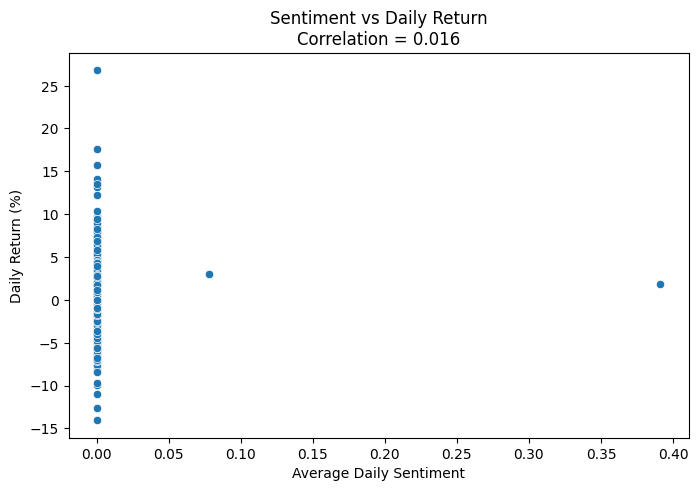

In [13]:
#scatter plot 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged_df['sentiment'],
    y=merged_df['daily_return']
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.3f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [14]:
# sentimetn classification
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
merged_df['sentiment_category'] = merged_df['sentiment'].apply(classify_sentiment)

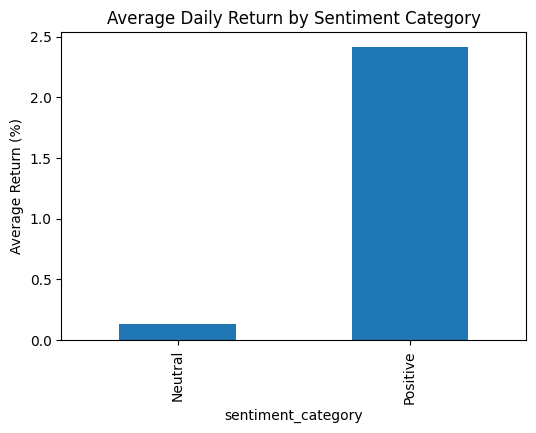

In [15]:
#barchart
avg_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
)

plt.figure(figsize=(6,4))

avg_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

The correlation coefficient for this stock was approximately 0.016, indicating an extremely weak positive relationship between financial news sentiment and daily stock returns. This suggests that while sentiment may slightly influence market behavior, it is not a strong standalone predictor of stock price movement. The result aligns with expectations in financial analysis, where prices are affected by multiple economic and behavioral factors beyond news headlines alone.

In [16]:
print(merged_df.shape)
print(merged_df[['sentiment','daily_return']].corr())
print(merged_df.head())

(3773, 4)
              sentiment  daily_return
sentiment      1.000000      0.016391
daily_return   0.016391      1.000000
    date_only  daily_return  sentiment sentiment_category
1  2009-01-05     -0.551871        0.0            Neutral
2  2009-01-06      6.104327        0.0            Neutral
3  2009-01-07     -2.022318        0.0            Neutral
4  2009-01-08      1.708189        0.0            Neutral
5  2009-01-09     -2.886633        0.0            Neutral


Many trading days contained no associated news headlines and were assigned neutral sentiment values. This may reduce the observed correlation strength between sentiment and stock returns.